In [1]:
import os
os.environ['KAGGLE_USERNAME'] = "emirhankaraoban"
os.environ['KAGGLE_KEY'] = "KGAT_e8eb029bd1e03040138bd081bf1ca389"

!pip install kaggle -q
!kaggle datasets download -d puneet6060/intel-image-classification
!unzip -q intel-image-classification.zip -d intel_data
print("Dataset hazır!")

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:01<00:00, 230MB/s]

Dataset hazır!


In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [3]:
DATA_DIR_TRAIN = "intel_data/seg_train/seg_train"
DATA_DIR_TEST  = "intel_data/seg_test/seg_test"

def get_transforms():
    train_tf = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3),
    ])
    val_tf = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3),
    ])
    return train_tf, val_tf

train_tf, val_tf = get_transforms()

full_train = datasets.ImageFolder(DATA_DIR_TRAIN, transform=train_tf)
val_size   = int(0.2 * len(full_train))
train_size = len(full_train) - val_size
train_ds, val_ds = random_split(full_train, [train_size, val_size],
                                generator=torch.Generator().manual_seed(SEED))

val_ds.dataset.transform = val_tf
test_ds = datasets.ImageFolder(DATA_DIR_TEST, transform=val_tf)

CLASS_NAMES = full_train.classes
NUM_CLASSES  = len(CLASS_NAMES)
print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Train: {train_size} | Val: {val_size} | Test: {len(test_ds)}")

Classes (6): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Train: 11228 | Val: 2806 | Test: 3000


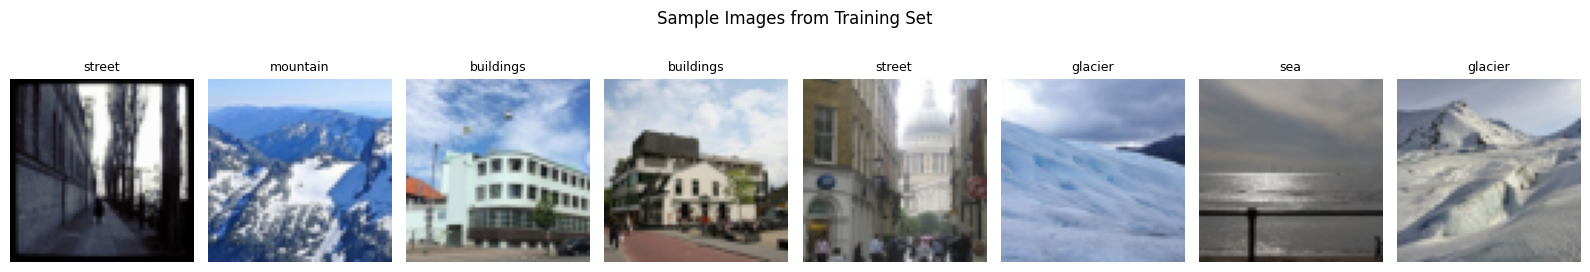

In [4]:
def make_loaders(batch_size=32):
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader, test_loader

def show_samples(dataset, class_names, n=8):
    fig, axes = plt.subplots(1, n, figsize=(16, 3))
    indices = random.sample(range(len(dataset)), n)
    for ax, idx in zip(axes, indices):
        img, label = dataset[idx]
        img = img.permute(1, 2, 0).numpy()
        img = (img * 0.5 + 0.5).clip(0, 1)
        ax.imshow(img)
        ax.set_title(class_names[label], fontsize=9)
        ax.axis("off")
    plt.suptitle("Sample Images from Training Set")
    plt.tight_layout()
    plt.show()

show_samples(train_ds, CLASS_NAMES)

In [5]:
def get_activation(name):
    return {"relu": nn.ReLU(), "tanh": nn.Tanh(), "sigmoid": nn.Sigmoid()}[name]

class CNN(nn.Module):
    def __init__(
        self,
        num_classes=6,
        num_conv_layers=3,
        conv_kernel_size=3,
        pool_kernel_size=2,
        pool_stride=2,
        conv_dropout=0.2,
        fc_hidden_units=256,
        fc_dropout=0.5,
        activation_fn="relu",
    ):
        super().__init__()

        pad = conv_kernel_size // 2
        conv_blocks = []
        in_ch = 3
        out_ch = 32
        for i in range(num_conv_layers):
            conv_blocks += [
                nn.Conv2d(in_ch, out_ch, kernel_size=conv_kernel_size, padding=pad),
                nn.BatchNorm2d(out_ch),
                get_activation(activation_fn),
                nn.MaxPool2d(kernel_size=pool_kernel_size, stride=pool_stride),
                nn.Dropout2d(conv_dropout),
            ]
            in_ch = out_ch
            out_ch = min(out_ch * 2, 512)

        self.features = nn.Sequential(*conv_blocks)

        with torch.no_grad():
            dummy = torch.zeros(1, 3, 64, 64)
            flat  = self.features(dummy).view(1, -1).shape[1]

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat, fc_hidden_units),
            get_activation(activation_fn),
            nn.Dropout(fc_dropout),
            nn.Linear(fc_hidden_units, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

# Test et
test_model = CNN().to(DEVICE)
dummy = torch.zeros(1, 3, 64, 64).to(DEVICE)
out = test_model(dummy)
print(f"Model çalışıyor! Output shape: {out.shape}")
print(f"Toplam parametre: {sum(p.numel() for p in test_model.parameters()):,}")
del test_model

Model çalışıyor! Output shape: torch.Size([1, 6])
Toplam parametre: 2,192,646


In [6]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out  = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
        correct    += (out.argmax(1) == y).sum().item()
        total      += X.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            out  = model(X)
            loss = criterion(out, y)
            total_loss += loss.item() * X.size(0)
            correct    += (out.argmax(1) == y).sum().item()
            total      += X.size(0)
    return total_loss / total, correct / total


def plot_curves(history, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history["train_loss"]) + 1)
    ax1.plot(epochs, history["train_loss"], label="Train Loss")
    ax1.plot(epochs, history["val_loss"],   label="Val Loss")
    ax1.set_title(f"{title} – Loss")
    ax1.set_xlabel("Epoch"); ax1.legend()
    ax2.plot(epochs, history["train_acc"], label="Train Acc")
    ax2.plot(epochs, history["val_acc"],   label="Val Acc")
    ax2.set_title(f"{title} – Accuracy")
    ax2.set_xlabel("Epoch"); ax2.legend()
    plt.tight_layout(); plt.show()


def run_experiment(config, num_epochs=10, return_model=False):
    train_loader, val_loader, _ = make_loaders(config.get("batch_size", 32))

    model = CNN(
        num_classes      = NUM_CLASSES,
        num_conv_layers  = config.get("num_conv_layers", 3),
        conv_kernel_size = config.get("conv_kernel_size", 3),
        pool_kernel_size = config.get("pool_kernel_size", 2),
        pool_stride      = config.get("pool_stride", 2),
        conv_dropout     = config.get("conv_dropout", 0.2),
        fc_hidden_units  = config.get("fc_hidden_units", 256),
        fc_dropout       = config.get("fc_dropout", 0.5),
        activation_fn    = config.get("activation_fn", "relu"),
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    opt_name  = config.get("optimizer_type", "adam")
    lr        = 1e-3
    if opt_name == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif opt_name == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
        optimizer = optim.RMSprop(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
        print(f"  Epoch {epoch+1:>2}/{num_epochs}  "
              f"train_loss={tr_loss:.4f}  val_loss={vl_loss:.4f}  "
              f"train_acc={tr_acc:.4f}  val_acc={vl_acc:.4f}")

    if return_model:
        return best_val_acc, history, model
    return best_val_acc, history

print("Fonksiyonlar tanımlandı!")

Fonksiyonlar tanımlandı!


BASELINE MODEL
  Epoch  1/10  train_loss=1.2741  val_loss=0.8900  train_acc=0.5174  val_acc=0.6493
  Epoch  2/10  train_loss=1.0629  val_loss=0.8281  train_acc=0.5908  val_acc=0.6835
  Epoch  3/10  train_loss=0.9922  val_loss=0.7449  train_acc=0.6217  val_acc=0.7192
  Epoch  4/10  train_loss=0.9532  val_loss=0.7441  train_acc=0.6415  val_acc=0.7131
  Epoch  5/10  train_loss=0.9129  val_loss=0.6966  train_acc=0.6559  val_acc=0.7477
  Epoch  6/10  train_loss=0.8659  val_loss=0.7416  train_acc=0.6763  val_acc=0.7149
  Epoch  7/10  train_loss=0.8447  val_loss=0.6449  train_acc=0.6812  val_acc=0.7698
  Epoch  8/10  train_loss=0.8025  val_loss=0.6273  train_acc=0.7007  val_acc=0.7769
  Epoch  9/10  train_loss=0.7898  val_loss=0.6181  train_acc=0.7115  val_acc=0.7869
  Epoch 10/10  train_loss=0.7676  val_loss=0.5963  train_acc=0.7174  val_acc=0.7819

Baseline Best Val Acc: 0.7869


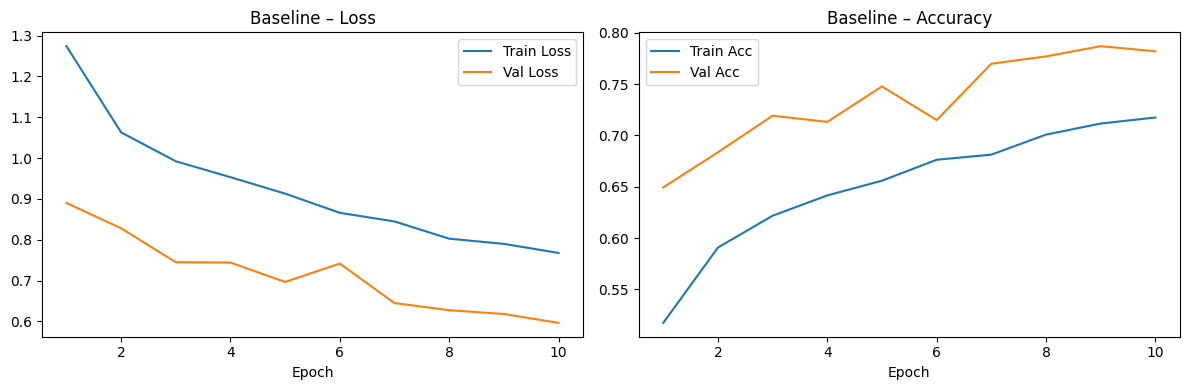

In [7]:
BASELINE = {
    "num_conv_layers" : 3,
    "conv_kernel_size": 3,
    "pool_kernel_size": 2,
    "pool_stride"     : 2,
    "conv_dropout"    : 0.2,
    "fc_hidden_units" : 256,
    "fc_dropout"      : 0.5,
    "activation_fn"   : "relu",
    "optimizer_type"  : "adam",
    "batch_size"      : 32,
}
BASELINE_EPOCHS = 10

print("=" * 60)
print("BASELINE MODEL")
print("=" * 60)
baseline_acc, baseline_history = run_experiment(BASELINE, num_epochs=BASELINE_EPOCHS)
print(f"\nBaseline Best Val Acc: {baseline_acc:.4f}")
plot_curves(baseline_history, title="Baseline")


EXPERIMENT: conv_kernel_size

  → conv_kernel_size = 1
  Epoch  1/10  train_loss=1.3981  val_loss=1.0956  train_acc=0.4654  val_acc=0.5905
  Epoch  2/10  train_loss=1.2282  val_loss=1.0495  train_acc=0.5258  val_acc=0.6016
  Epoch  3/10  train_loss=1.1965  val_loss=0.9615  train_acc=0.5400  val_acc=0.6390
  Epoch  4/10  train_loss=1.1402  val_loss=0.9498  train_acc=0.5680  val_acc=0.6336
  Epoch  5/10  train_loss=1.1275  val_loss=0.9032  train_acc=0.5783  val_acc=0.6511
  Epoch  6/10  train_loss=1.0927  val_loss=0.8741  train_acc=0.5912  val_acc=0.6857
  Epoch  7/10  train_loss=1.0755  val_loss=0.8957  train_acc=0.6031  val_acc=0.6810
  Epoch  8/10  train_loss=1.0598  val_loss=0.8335  train_acc=0.6014  val_acc=0.7006
  Epoch  9/10  train_loss=1.0485  val_loss=0.8358  train_acc=0.6105  val_acc=0.6981
  Epoch 10/10  train_loss=1.0347  val_loss=0.8839  train_acc=0.6180  val_acc=0.6800
  ✓ Best Val Acc: 0.7006

  → conv_kernel_size = 3
  Epoch  1/10  train_loss=1.3035  val_loss=0.9033  tr

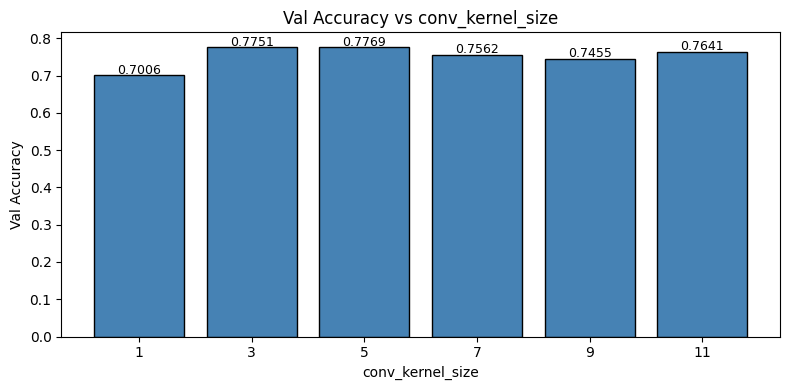

In [8]:
results = {}

def sweep(param_name, values):
    print(f"\n{'='*60}")
    print(f"EXPERIMENT: {param_name}")
    print(f"{'='*60}")
    accs = {}
    for v in values:
        cfg = BASELINE.copy()
        cfg[param_name] = v
        print(f"\n  → {param_name} = {v}")
        acc, _ = run_experiment(cfg, num_epochs=BASELINE_EPOCHS)
        accs[v] = round(acc, 4)
        print(f"  ✓ Best Val Acc: {acc:.4f}")
    results[param_name] = accs
    return accs

def plot_sweep(param_name, accs):
    vals = list(accs.keys())
    accs_list = list(accs.values())
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar([str(v) for v in vals], accs_list, color="steelblue", edgecolor="k")
    ax.set_title(f"Val Accuracy vs {param_name}")
    ax.set_xlabel(param_name)
    ax.set_ylabel("Val Accuracy")
    for i, a in enumerate(accs_list):
        ax.text(i, a + 0.003, f"{a:.4f}", ha="center", fontsize=9)
    plt.tight_layout()
    plt.show()

# DENEY 1 – conv_kernel_size
accs = sweep("conv_kernel_size", [1, 3, 5, 7, 9, 11])
plot_sweep("conv_kernel_size", accs)


EXPERIMENT: conv_dropout

  → conv_dropout = 0.0
  Epoch  1/10  train_loss=1.1321  val_loss=0.7707  train_acc=0.5755  val_acc=0.7124
  Epoch  2/10  train_loss=0.8790  val_loss=0.6893  train_acc=0.6757  val_acc=0.7619
  Epoch  3/10  train_loss=0.7742  val_loss=0.5787  train_acc=0.7223  val_acc=0.8058
  Epoch  4/10  train_loss=0.7101  val_loss=0.5385  train_acc=0.7471  val_acc=0.8186
  Epoch  5/10  train_loss=0.6608  val_loss=0.6492  train_acc=0.7652  val_acc=0.7776
  Epoch  6/10  train_loss=0.6134  val_loss=0.5290  train_acc=0.7805  val_acc=0.8168
  Epoch  7/10  train_loss=0.5821  val_loss=0.5154  train_acc=0.7939  val_acc=0.8175
  Epoch  8/10  train_loss=0.5604  val_loss=0.5643  train_acc=0.8032  val_acc=0.8058
  Epoch  9/10  train_loss=0.5365  val_loss=0.4808  train_acc=0.8135  val_acc=0.8350
  Epoch 10/10  train_loss=0.5116  val_loss=0.5191  train_acc=0.8222  val_acc=0.8133
  ✓ Best Val Acc: 0.8350

  → conv_dropout = 0.1
  Epoch  1/10  train_loss=1.2356  val_loss=0.8833  train_acc=

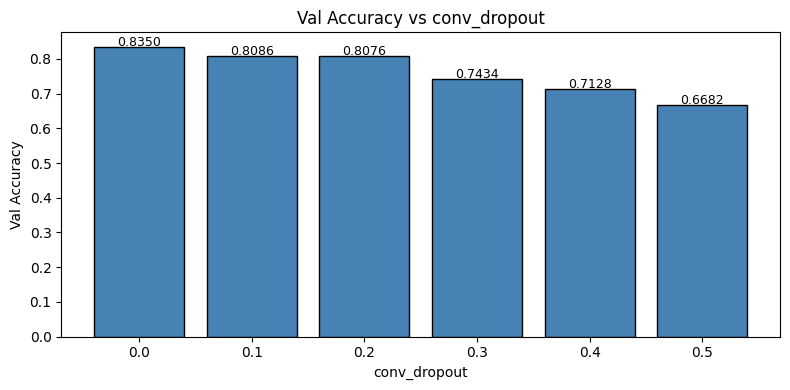

In [9]:
accs = sweep("conv_dropout", [0.0, 0.1, 0.2, 0.3, 0.4, 0.5])
plot_sweep("conv_dropout", accs)


EXPERIMENT: activation_fn

  → activation_fn = relu
  Epoch  1/10  train_loss=1.2216  val_loss=0.8829  train_acc=0.5262  val_acc=0.6454
  Epoch  2/10  train_loss=1.0600  val_loss=0.8084  train_acc=0.5914  val_acc=0.6942
  Epoch  3/10  train_loss=1.0022  val_loss=0.7937  train_acc=0.6252  val_acc=0.7135
  Epoch  4/10  train_loss=0.9541  val_loss=0.7498  train_acc=0.6388  val_acc=0.7028
  Epoch  5/10  train_loss=0.9112  val_loss=0.6837  train_acc=0.6518  val_acc=0.7466
  Epoch  6/10  train_loss=0.8787  val_loss=0.7237  train_acc=0.6758  val_acc=0.7416
  Epoch  7/10  train_loss=0.8486  val_loss=0.6304  train_acc=0.6875  val_acc=0.7748
  Epoch  8/10  train_loss=0.8110  val_loss=0.6526  train_acc=0.7007  val_acc=0.7559
  Epoch  9/10  train_loss=0.7894  val_loss=0.6416  train_acc=0.7150  val_acc=0.7755
  Epoch 10/10  train_loss=0.7847  val_loss=0.6155  train_acc=0.7108  val_acc=0.7872
  ✓ Best Val Acc: 0.7872

  → activation_fn = tanh
  Epoch  1/10  train_loss=1.1511  val_loss=0.9102  train

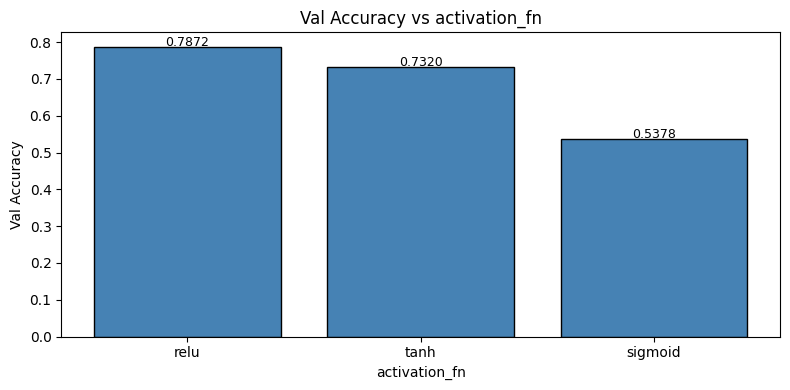

In [10]:
accs = sweep("activation_fn", ["relu", "tanh", "sigmoid"])
plot_sweep("activation_fn", accs)


EXPERIMENT: batch_size

  → batch_size = 8
  Epoch  1/10  train_loss=1.3390  val_loss=1.0055  train_acc=0.4776  val_acc=0.6108
  Epoch  2/10  train_loss=1.1926  val_loss=0.9152  train_acc=0.5247  val_acc=0.6372
  Epoch  3/10  train_loss=1.1224  val_loss=0.8641  train_acc=0.5576  val_acc=0.6522
  Epoch  4/10  train_loss=1.0608  val_loss=0.8245  train_acc=0.5802  val_acc=0.6632
  Epoch  5/10  train_loss=1.0092  val_loss=0.8581  train_acc=0.6084  val_acc=0.6575
  Epoch  6/10  train_loss=0.9647  val_loss=0.7700  train_acc=0.6316  val_acc=0.7035
  Epoch  7/10  train_loss=0.9326  val_loss=0.7110  train_acc=0.6437  val_acc=0.7327
  Epoch  8/10  train_loss=0.9004  val_loss=0.7107  train_acc=0.6602  val_acc=0.7341
  Epoch  9/10  train_loss=0.8625  val_loss=0.6953  train_acc=0.6762  val_acc=0.7438
  Epoch 10/10  train_loss=0.8323  val_loss=0.6601  train_acc=0.6999  val_acc=0.7705
  ✓ Best Val Acc: 0.7705

  → batch_size = 16
  Epoch  1/10  train_loss=1.2834  val_loss=0.9288  train_acc=0.5063  v

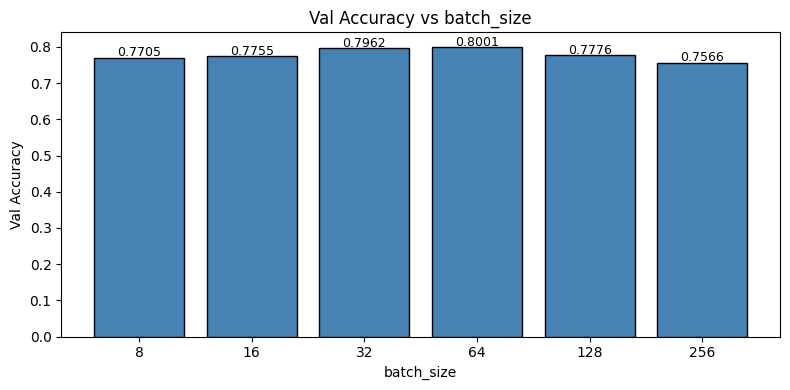

In [11]:
accs = sweep("batch_size", [8, 16, 32, 64, 128, 256])
plot_sweep("batch_size", accs)


EXPERIMENT: optimizer_type

  → optimizer_type = adam
  Epoch  1/10  train_loss=1.2715  val_loss=0.9504  train_acc=0.5137  val_acc=0.6123
  Epoch  2/10  train_loss=1.0836  val_loss=0.8892  train_acc=0.5728  val_acc=0.6586
  Epoch  3/10  train_loss=1.0142  val_loss=0.8627  train_acc=0.6042  val_acc=0.6725
  Epoch  4/10  train_loss=0.9641  val_loss=0.7745  train_acc=0.6311  val_acc=0.7135
  Epoch  5/10  train_loss=0.9165  val_loss=0.7419  train_acc=0.6559  val_acc=0.7234
  Epoch  6/10  train_loss=0.8918  val_loss=0.7138  train_acc=0.6565  val_acc=0.7434
  Epoch  7/10  train_loss=0.8539  val_loss=0.6660  train_acc=0.6770  val_acc=0.7623
  Epoch  8/10  train_loss=0.8363  val_loss=0.6573  train_acc=0.6840  val_acc=0.7666
  Epoch  9/10  train_loss=0.8053  val_loss=0.6270  train_acc=0.6961  val_acc=0.7744
  Epoch 10/10  train_loss=0.7702  val_loss=0.6228  train_acc=0.7113  val_acc=0.7669
  ✓ Best Val Acc: 0.7744

  → optimizer_type = sgd
  Epoch  1/10  train_loss=1.1771  val_loss=0.8896  tra

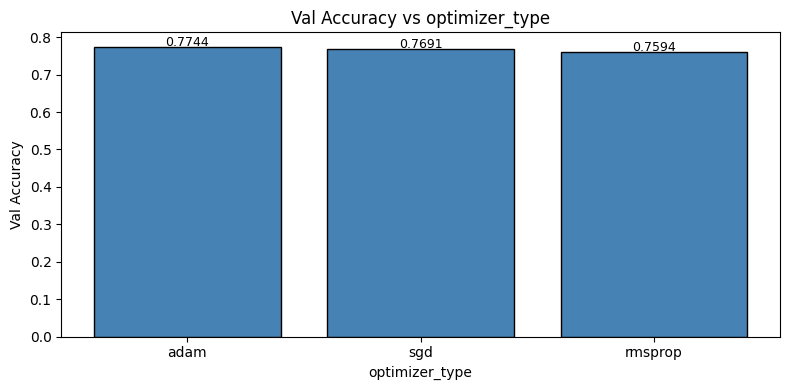

In [12]:
accs = sweep("optimizer_type", ["adam", "sgd", "rmsprop"])
plot_sweep("optimizer_type", accs)


EXPERIMENT: num_conv_layers

  → num_conv_layers = 1
  Epoch  1/10  train_loss=1.7731  val_loss=1.1563  train_acc=0.4202  val_acc=0.5364
  Epoch  2/10  train_loss=1.3074  val_loss=1.0434  train_acc=0.4777  val_acc=0.5895
  Epoch  3/10  train_loss=1.2331  val_loss=1.0505  train_acc=0.5061  val_acc=0.5902
  Epoch  4/10  train_loss=1.1757  val_loss=0.9909  train_acc=0.5204  val_acc=0.6475
  Epoch  5/10  train_loss=1.1294  val_loss=0.9329  train_acc=0.5474  val_acc=0.6401
  Epoch  6/10  train_loss=1.0993  val_loss=0.8851  train_acc=0.5639  val_acc=0.6793
  Epoch  7/10  train_loss=1.0721  val_loss=0.9175  train_acc=0.5740  val_acc=0.6764
  Epoch  8/10  train_loss=1.0331  val_loss=0.8983  train_acc=0.5854  val_acc=0.6782
  Epoch  9/10  train_loss=1.0016  val_loss=0.8905  train_acc=0.5988  val_acc=0.6689
  Epoch 10/10  train_loss=0.9821  val_loss=0.8950  train_acc=0.6218  val_acc=0.6572
  ✓ Best Val Acc: 0.6793

  → num_conv_layers = 2
  Epoch  1/10  train_loss=1.4331  val_loss=0.9857  train

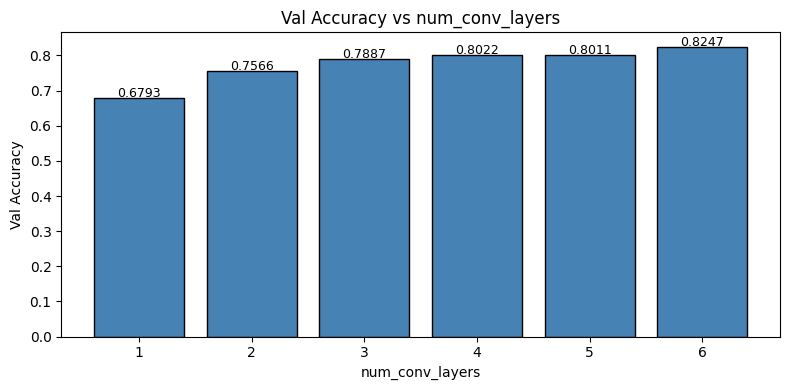

In [13]:
accs = sweep("num_conv_layers", [1, 2, 3, 4, 5, 6])
plot_sweep("num_conv_layers", accs)


EXPERIMENT: fc_hidden_units

  → fc_hidden_units = 64
  Epoch  1/10  train_loss=1.4189  val_loss=1.0238  train_acc=0.3881  val_acc=0.5909
  Epoch  2/10  train_loss=1.2625  val_loss=0.9900  train_acc=0.4484  val_acc=0.6276
  Epoch  3/10  train_loss=1.2152  val_loss=0.9320  train_acc=0.4765  val_acc=0.6454
  Epoch  4/10  train_loss=1.1870  val_loss=0.9425  train_acc=0.4914  val_acc=0.6308
  Epoch  5/10  train_loss=1.1595  val_loss=0.8924  train_acc=0.5081  val_acc=0.6461
  Epoch  6/10  train_loss=1.1618  val_loss=0.8715  train_acc=0.5050  val_acc=0.6461
  Epoch  7/10  train_loss=1.1233  val_loss=0.8764  train_acc=0.5094  val_acc=0.6597
  Epoch  8/10  train_loss=1.1214  val_loss=0.8603  train_acc=0.5174  val_acc=0.6557
  Epoch  9/10  train_loss=1.1069  val_loss=0.8497  train_acc=0.5290  val_acc=0.6753
  Epoch 10/10  train_loss=1.1007  val_loss=0.8436  train_acc=0.5208  val_acc=0.6639
  ✓ Best Val Acc: 0.6753

  → fc_hidden_units = 128
  Epoch  1/10  train_loss=1.3276  val_loss=0.8752  tr

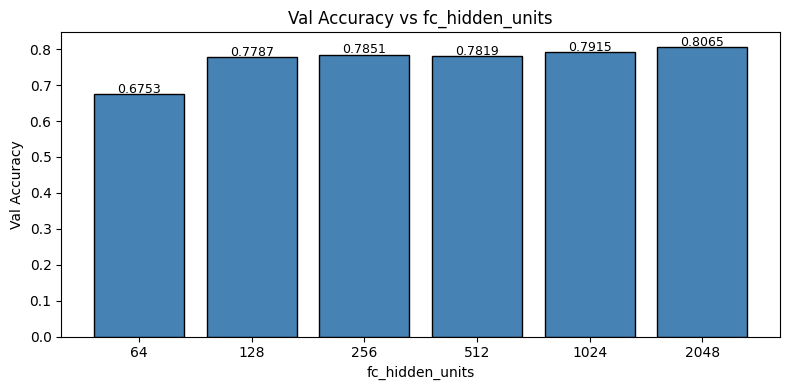

In [14]:
accs = sweep("fc_hidden_units", [64, 128, 256, 512, 1024, 2048])
plot_sweep("fc_hidden_units", accs)

In [16]:
import json
from google.colab import drive
drive.mount('/content/drive')

results["conv_kernel_size"] = {1: 0.6935, 3: 0.7637, 5: 0.7833, 7: 0.7548, 9: 0.7541, 11: 0.7406}
results["conv_dropout"]     = {0.0: 0.8346, 0.1: 0.7976, 0.2: 0.7883, 0.3: 0.7431, 0.4: 0.7042, 0.5: 0.6622}
results["activation_fn"]    = {"relu": 0.7940, "tanh": 0.7452, "sigmoid": 0.5499}
results["batch_size"]       = {8: 0.7619, 16: 0.7901, 32: 0.7883, 64: 0.7926, 128: 0.7808, 256: 0.7637}
results["optimizer_type"]   = {"adam": 0.7876, "sgd": 0.7790, "rmsprop": 0.7619}
results["num_conv_layers"]  = {1: 0.6842, 2: 0.7559, 3: 0.7783, 4: 0.7858, 5: 0.7954, 6: 0.8264}
results["fc_hidden_units"]  = {64: 0.7199, 128: 0.7726, 256: 0.7976, 512: 0.7855, 1024: 0.7908, 2048: 0.8026}

with open("/content/drive/MyDrive/cmpe452_results.json", "w") as f:
    json.dump(results, f)

print("Sonuçlar kaydedildi!")

Mounted at /content/drive
Sonuçlar kaydedildi!



EXPERIMENT: pool_kernel_size

  → pool_kernel_size = 2
  Epoch  1/10  train_loss=1.2815  val_loss=0.8987  train_acc=0.5120  val_acc=0.6372
  Epoch  2/10  train_loss=1.0628  val_loss=0.8156  train_acc=0.5881  val_acc=0.6782
  Epoch  3/10  train_loss=1.0039  val_loss=0.8026  train_acc=0.6134  val_acc=0.6900
  Epoch  4/10  train_loss=0.9479  val_loss=0.7518  train_acc=0.6469  val_acc=0.7028
  Epoch  5/10  train_loss=0.9178  val_loss=0.6793  train_acc=0.6626  val_acc=0.7566
  Epoch  6/10  train_loss=0.8751  val_loss=0.6847  train_acc=0.6768  val_acc=0.7530
  Epoch  7/10  train_loss=0.8433  val_loss=0.6580  train_acc=0.6904  val_acc=0.7573
  Epoch  8/10  train_loss=0.8210  val_loss=0.6709  train_acc=0.6990  val_acc=0.7530
  Epoch  9/10  train_loss=0.7859  val_loss=0.6198  train_acc=0.7174  val_acc=0.7726
  Epoch 10/10  train_loss=0.7554  val_loss=0.6027  train_acc=0.7284  val_acc=0.7855
  ✓ Best Val Acc: 0.7855

  → pool_kernel_size = 3
  Epoch  1/10  train_loss=1.2781  val_loss=0.9859  tr

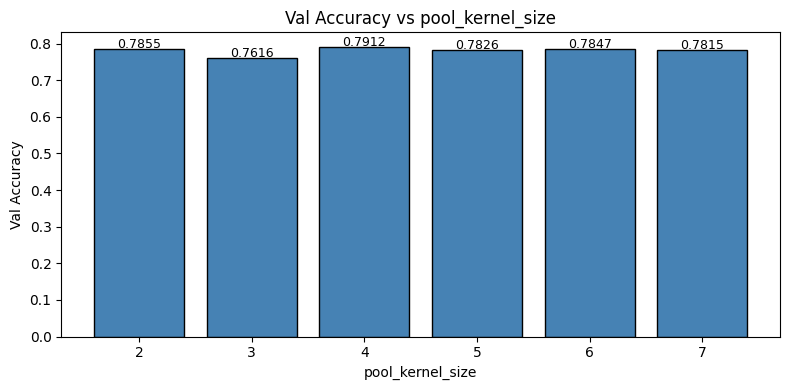

In [17]:
accs = sweep("pool_kernel_size", [2, 3, 4, 5, 6, 7])
plot_sweep("pool_kernel_size", accs)


EXPERIMENT: pool_stride

  → pool_stride = 1
  Epoch  1/10  train_loss=5.7219  val_loss=1.6347  train_acc=0.2110  val_acc=0.2801
  Epoch  2/10  train_loss=1.7241  val_loss=1.5979  train_acc=0.2457  val_acc=0.2880
  Epoch  3/10  train_loss=1.6821  val_loss=1.5403  train_acc=0.2641  val_acc=0.3143
  Epoch  4/10  train_loss=1.6594  val_loss=1.5934  train_acc=0.2734  val_acc=0.2769
  Epoch  5/10  train_loss=1.6466  val_loss=1.5559  train_acc=0.2759  val_acc=0.2944
  Epoch  6/10  train_loss=1.5966  val_loss=1.4726  train_acc=0.3127  val_acc=0.3721
  Epoch  7/10  train_loss=1.5496  val_loss=1.4047  train_acc=0.3286  val_acc=0.3738
  Epoch  8/10  train_loss=1.5536  val_loss=1.4012  train_acc=0.3370  val_acc=0.4241
  Epoch  9/10  train_loss=1.5187  val_loss=1.3908  train_acc=0.3524  val_acc=0.3785
  Epoch 10/10  train_loss=1.5192  val_loss=1.2898  train_acc=0.3553  val_acc=0.4344
  ✓ Best Val Acc: 0.4344

  → pool_stride = 2
  Epoch  1/10  train_loss=1.2330  val_loss=1.0303  train_acc=0.5279 

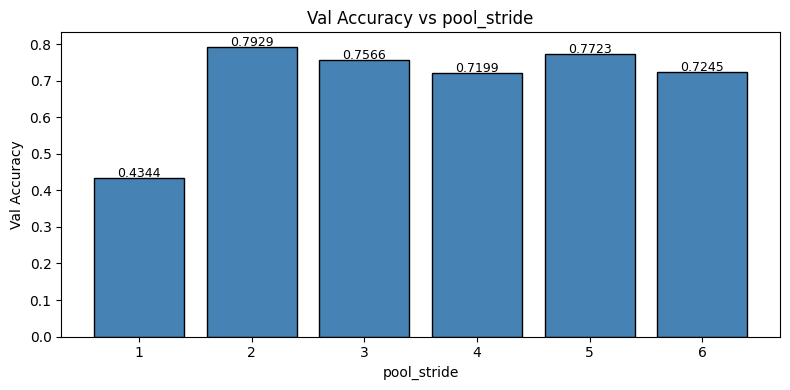

In [18]:
accs = sweep("pool_stride", [1, 2, 3, 4, 5, 6])
plot_sweep("pool_stride", accs)


EXPERIMENT: fc_dropout

  → fc_dropout = 0.0
  Epoch  1/10  train_loss=1.1508  val_loss=0.8654  train_acc=0.5706  val_acc=0.6714
  Epoch  2/10  train_loss=0.8680  val_loss=0.7479  train_acc=0.6690  val_acc=0.7206
  Epoch  3/10  train_loss=0.7798  val_loss=0.6350  train_acc=0.7122  val_acc=0.7627
  Epoch  4/10  train_loss=0.7061  val_loss=0.6461  train_acc=0.7432  val_acc=0.7651
  Epoch  5/10  train_loss=0.6609  val_loss=0.6161  train_acc=0.7526  val_acc=0.7712
  Epoch  6/10  train_loss=0.6252  val_loss=0.5732  train_acc=0.7702  val_acc=0.7926
  Epoch  7/10  train_loss=0.5846  val_loss=0.5375  train_acc=0.7852  val_acc=0.8093
  Epoch  8/10  train_loss=0.5467  val_loss=0.6036  train_acc=0.7995  val_acc=0.7726
  Epoch  9/10  train_loss=0.5164  val_loss=0.5355  train_acc=0.8115  val_acc=0.8086
  Epoch 10/10  train_loss=0.4947  val_loss=0.5366  train_acc=0.8172  val_acc=0.8076
  ✓ Best Val Acc: 0.8093

  → fc_dropout = 0.1
  Epoch  1/10  train_loss=1.1115  val_loss=0.8132  train_acc=0.5813

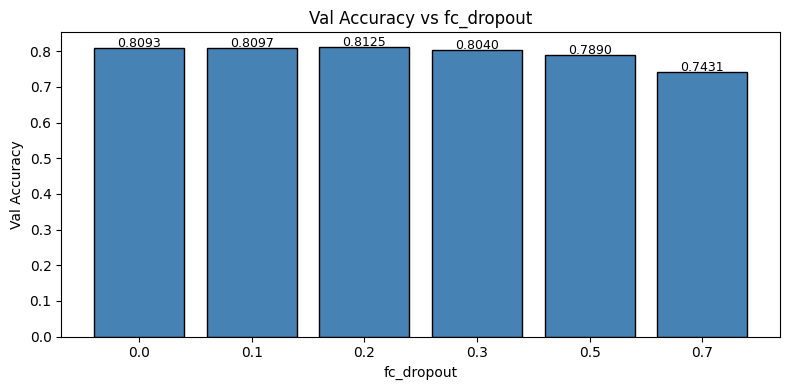

In [19]:
accs = sweep("fc_dropout", [0.0, 0.1, 0.2, 0.3, 0.5, 0.7])
plot_sweep("fc_dropout", accs)


  → num_epochs = 5
  Epoch  1/5  train_loss=1.2795  val_loss=0.9498  train_acc=0.5053  val_acc=0.6329
  Epoch  2/5  train_loss=1.0566  val_loss=0.8383  train_acc=0.5842  val_acc=0.6857
  Epoch  3/5  train_loss=1.0019  val_loss=0.7898  train_acc=0.6160  val_acc=0.7202
  Epoch  4/5  train_loss=0.9543  val_loss=0.7424  train_acc=0.6409  val_acc=0.7074
  Epoch  5/5  train_loss=0.9091  val_loss=0.7005  train_acc=0.6535  val_acc=0.7306
  ✓ Best Val Acc: 0.7306

  → num_epochs = 10
  Epoch  1/10  train_loss=1.2486  val_loss=0.9734  train_acc=0.5228  val_acc=0.6230
  Epoch  2/10  train_loss=1.0585  val_loss=0.7687  train_acc=0.5938  val_acc=0.7067
  Epoch  3/10  train_loss=0.9761  val_loss=0.7468  train_acc=0.6236  val_acc=0.7106
  Epoch  4/10  train_loss=0.9346  val_loss=0.7112  train_acc=0.6441  val_acc=0.7395
  Epoch  5/10  train_loss=0.8872  val_loss=0.7089  train_acc=0.6703  val_acc=0.7288
  Epoch  6/10  train_loss=0.8486  val_loss=0.6154  train_acc=0.6858  val_acc=0.7730
  Epoch  7/10  

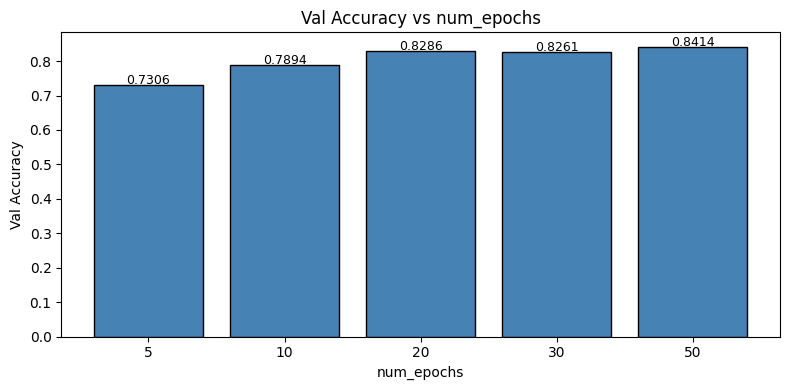

In [20]:
accs_epochs = {}
for ep in [5, 10, 20, 30, 50]:
    print(f"\n  → num_epochs = {ep}")
    acc, hist = run_experiment(BASELINE, num_epochs=ep)
    accs_epochs[ep] = round(acc, 4)
    print(f"  ✓ Best Val Acc: {acc:.4f}")

results["num_epochs"] = accs_epochs
plot_sweep("num_epochs", accs_epochs)

BEST CONFIGURATION:
  conv_kernel_size: 5
  conv_dropout: 0.0
  activation_fn: relu
  batch_size: 64
  optimizer_type: adam
  num_conv_layers: 6
  fc_hidden_units: 2048
  pool_kernel_size: 2
  pool_stride: 2
  fc_dropout: 0.0
  num_epochs: 50

Training Best Model...
  Epoch  1/50  train_loss=1.0910  val_loss=0.8570  train_acc=0.5635  val_acc=0.6639
  Epoch  2/50  train_loss=0.7750  val_loss=0.8395  train_acc=0.7146  val_acc=0.6942
  Epoch  3/50  train_loss=0.6341  val_loss=0.6847  train_acc=0.7746  val_acc=0.7555
  Epoch  4/50  train_loss=0.5643  val_loss=0.6377  train_acc=0.8019  val_acc=0.7705
  Epoch  5/50  train_loss=0.4935  val_loss=0.7844  train_acc=0.8312  val_acc=0.7377
  Epoch  6/50  train_loss=0.4654  val_loss=0.5978  train_acc=0.8352  val_acc=0.7990
  Epoch  7/50  train_loss=0.4201  val_loss=0.8136  train_acc=0.8525  val_acc=0.7537
  Epoch  8/50  train_loss=0.3804  val_loss=0.5673  train_acc=0.8680  val_acc=0.8100
  Epoch  9/50  train_loss=0.3485  val_loss=0.6991  train_acc=

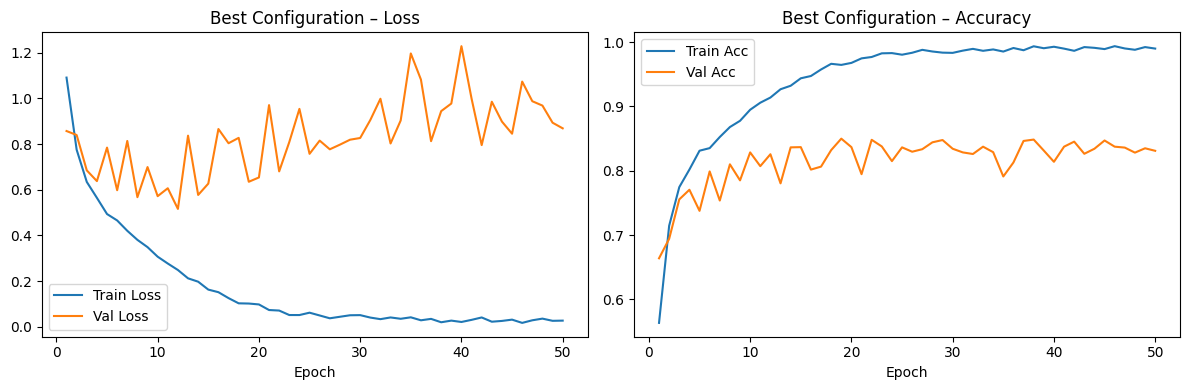

Model kaydedildi!


In [21]:
BEST_CONFIG = {
    "conv_kernel_size": 5,
    "conv_dropout"    : 0.0,
    "activation_fn"   : "relu",
    "batch_size"      : 64,
    "optimizer_type"  : "adam",
    "num_conv_layers" : 6,
    "fc_hidden_units" : 2048,
    "pool_kernel_size": 2,  # 4'ten 2'ye düşürdük
    "pool_stride"     : 2,
    "fc_dropout"      : 0.0,
}
BEST_EPOCHS = 50

print("BEST CONFIGURATION:")
for k, v in BEST_CONFIG.items():
    print(f"  {k}: {v}")
print(f"  num_epochs: {BEST_EPOCHS}")

print("\nTraining Best Model...")
best_acc, best_history, best_model = run_experiment(
    BEST_CONFIG, num_epochs=BEST_EPOCHS, return_model=True
)
print(f"\nBest Model Val Acc: {best_acc:.4f}")
plot_curves(best_history, title="Best Configuration")

torch.save(best_model.state_dict(), "/content/drive/MyDrive/best_model.pth")
print("Model kaydedildi!")

Test Accuracy: 0.8377

Classification Report:
              precision    recall  f1-score   support

   buildings       0.89      0.77      0.82       437
      forest       0.90      0.98      0.94       474
     glacier       0.85      0.69      0.76       553
    mountain       0.75      0.86      0.80       525
         sea       0.79      0.89      0.84       510
      street       0.88      0.85      0.87       501

    accuracy                           0.84      3000
   macro avg       0.84      0.84      0.84      3000
weighted avg       0.84      0.84      0.84      3000



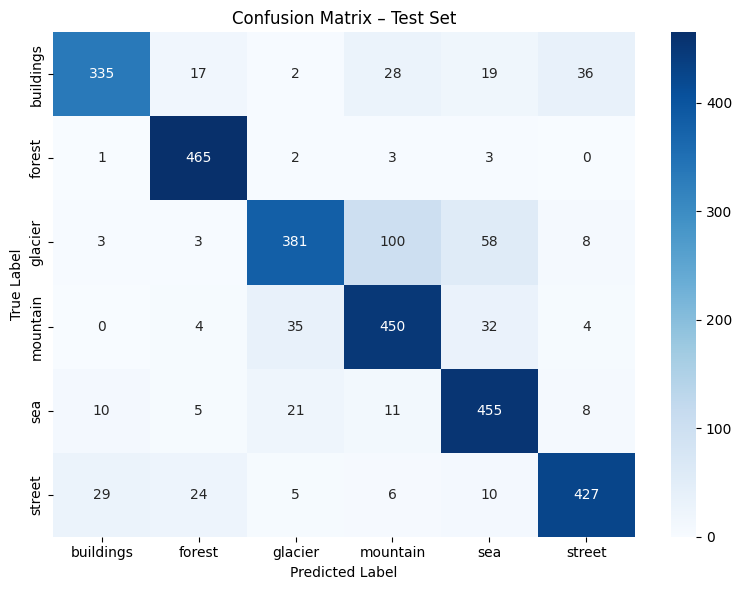

In [22]:
_, _, test_loader = make_loaders(BEST_CONFIG.get("batch_size", 64))

best_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X, y in test_loader:
        X = X.to(DEVICE)
        preds = best_model(X).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(y.numpy())

import numpy as np
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
print(f"Test Accuracy: {test_acc:.4f}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix – Test Set")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

In [23]:
!pip install gradio -q

import gradio as gr
from PIL import Image
import torchvision.transforms as transforms
import torch

# Transform
infer_tf = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

def predict(image):
    img = infer_tf(image).unsqueeze(0).to(DEVICE)
    best_model.eval()
    with torch.no_grad():
        out = best_model(img)
        probs = torch.softmax(out, dim=1)[0]
    return {CLASS_NAMES[i]: float(probs[i]) for i in range(NUM_CLASSES)}

demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=6),
    title="Intel Image Classification",
    description="Bir görsel yükle, model sınıfı tahmin etsin!"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5fbd4191970c97b3ae.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
